In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_predict, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

### Загрузим подготовленные данные из ноутбука data.ipynb

In [10]:
df = pd.read_csv('ObesityDataSet.csv')
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


In [8]:
x = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=42, stratify=y)

### Строим базовую модель логистической регрессии

In [4]:
def make_model(pipeline, x, y):
    stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    y_pred_cv_full = cross_val_predict(estimator=pipeline, 
                                   X=x, 
                                   y=y, 
                                   cv=stratified_kfold, 
                                   n_jobs=-1)

    print("Classification Report - Full Model CV:")
    print(classification_report(y_train, y_pred_cv_full, target_names=y.unique()))

    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_matrix(y_train, y_pred_cv_full), annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix - Full Model CV')
    plt.show()

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Overweight_Level_II       0.86      0.98      0.91       204
 Overweight_Level_I       0.86      0.67      0.75       215
Insufficient_Weight       0.91      0.86      0.88       263
     Obesity_Type_I       0.92      0.98      0.95       223
    Obesity_Type_II       0.98      1.00      0.99       243
      Normal_Weight       0.76      0.78      0.77       217
   Obesity_Type_III       0.75      0.77      0.76       218

           accuracy                           0.86      1583
          macro avg       0.86      0.86      0.86      1583
       weighted avg       0.86      0.86      0.86      1583



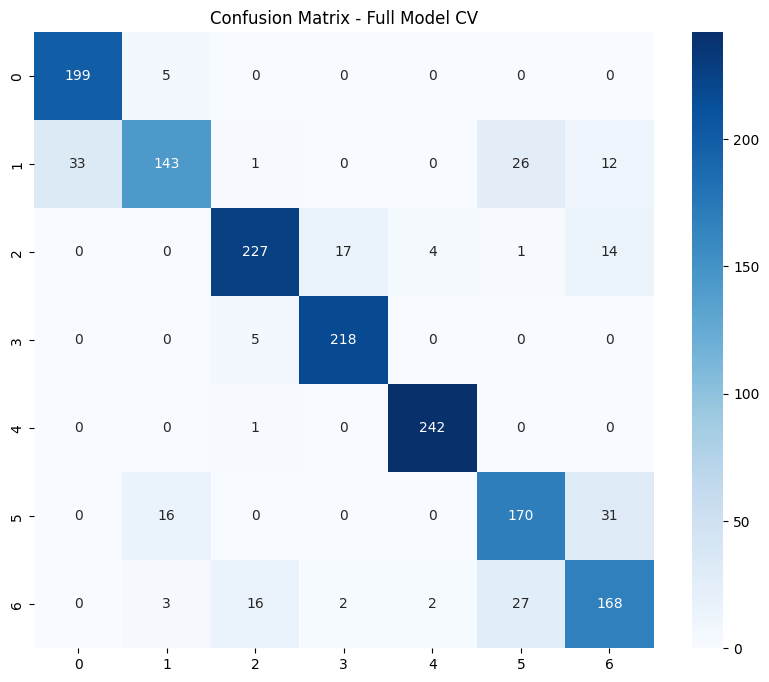

In [5]:
pipeline = make_pipeline(
        StandardScaler(),
        LogisticRegression(random_state=42)
    )
make_model(pipeline, X_train, y_train)

### Сделаем подбор гиперпараметров с помощью GridSearch

In [13]:
pipeline = make_pipeline(
        StandardScaler(),
        LogisticRegression(random_state=42)
    )

param_grid = [{
    'logisticregression__multi_class': ['ovr', 'multinomial', 'auto'],
    'logisticregression__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'logisticregression__penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'logisticregression__solver': ['liblinear', 'saga', 'lbfgs', 'newton-cg', 'sag'],
    'logisticregression__class_weight': [None, 'balanced', {0: 1, 1: 5}]
}]

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_weighted',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая точность:", grid_search.best_score_)

C:\Users\Пользователь\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
4970 fits failed out of a total of 6300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
315 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Пользователь\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Пользователь\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\Пользователь\AppDat

Лучшие параметры: {'logisticregression__C': 1000, 'logisticregression__class_weight': 'balanced', 'logisticregression__multi_class': 'multinomial', 'logisticregression__penalty': 'l2', 'logisticregression__solver': 'newton-cg'}
Лучшая точность: 0.9569806535448745


Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Overweight_Level_II       0.95      0.98      0.96       204
 Overweight_Level_I       0.96      0.93      0.94       215
Insufficient_Weight       0.98      0.95      0.97       263
     Obesity_Type_I       0.98      0.99      0.98       223
    Obesity_Type_II       0.98      1.00      0.99       243
      Normal_Weight       0.92      0.93      0.93       217
   Obesity_Type_III       0.92      0.92      0.92       218

           accuracy                           0.96      1583
          macro avg       0.96      0.96      0.96      1583
       weighted avg       0.96      0.96      0.96      1583



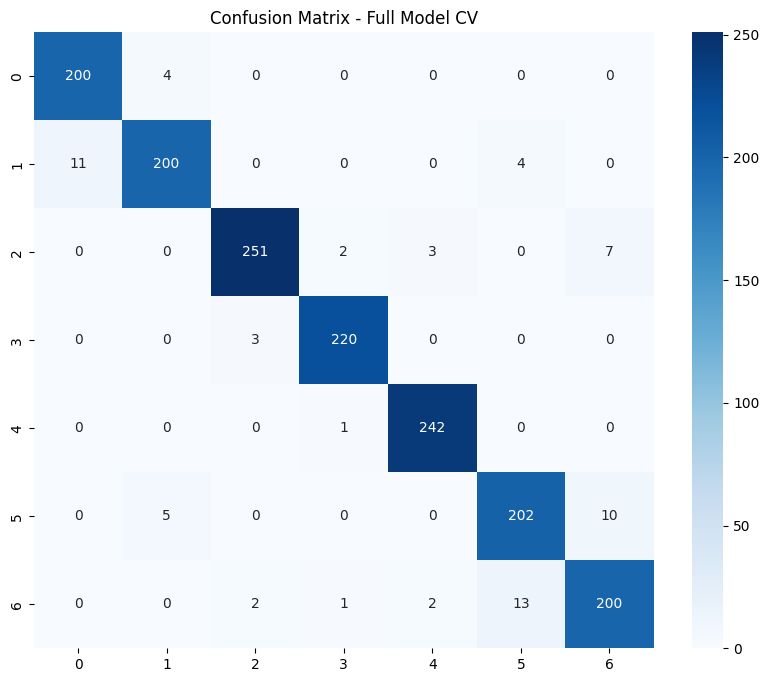

In [14]:
pipeline = make_pipeline(
        StandardScaler(),
        LogisticRegression(C = 1000, class_weight='balanced',  multi_class='multinomial', penalty='l2', solver='newton-cg', random_state=42)
    )
make_model(pipeline, X_train, y_train)

### Теперь попробуем использовать полиномы в логистической регрессии

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Overweight_Level_II       0.87      0.92      0.90       204
 Overweight_Level_I       0.79      0.72      0.75       215
Insufficient_Weight       0.92      0.92      0.92       263
     Obesity_Type_I       0.97      0.97      0.97       223
    Obesity_Type_II       0.98      1.00      0.99       243
      Normal_Weight       0.81      0.82      0.81       217
   Obesity_Type_III       0.84      0.84      0.84       218

           accuracy                           0.89      1583
          macro avg       0.88      0.88      0.88      1583
       weighted avg       0.89      0.89      0.89      1583



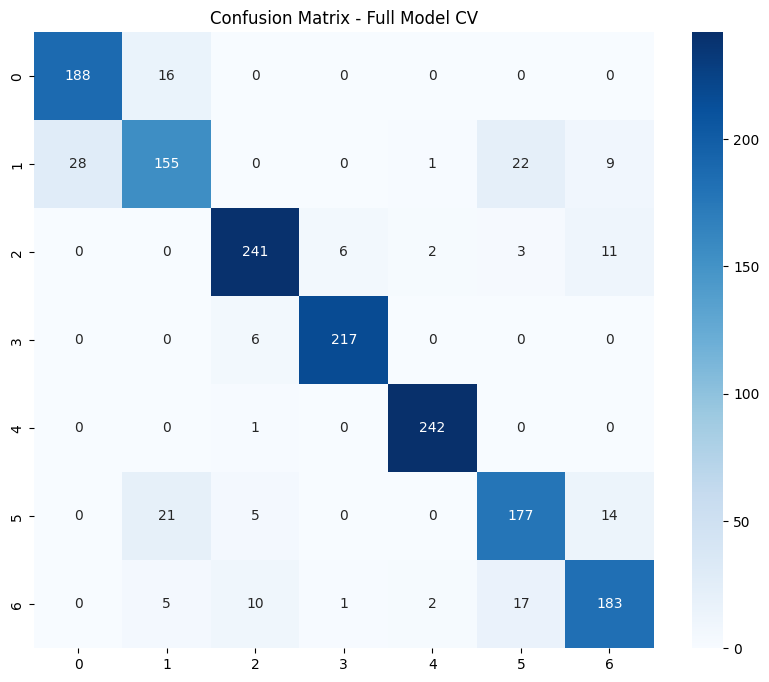

In [20]:
pipeline = make_pipeline(
        PolynomialFeatures(),
        StandardScaler(),
        LogisticRegression(random_state=42)
    )
make_model(pipeline, X_train, y_train)

In [29]:
pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=42))
])

param_grid = [{
    'clf__multi_class': ['ovr', 'multinomial'],
    'clf__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'clf__penalty': ['l1', 'l2', 'elasticnet'],
    'clf__solver': ['liblinear', 'saga', 'lbfgs'],
    'clf__class_weight': [None, 'balanced'],
    'poly__degree': [2, 3],
    'poly__interaction_only': [True, False]
}]

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_weighted',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая точность:", grid_search.best_score_)

KeyboardInterrupt: 

[I 2025-12-26 00:00:28,298] A new study created in memory with name: no-name-4db800cd-315b-4b16-9f8b-d7812134c835
  0%|          | 0/100 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.71923:   1%|          | 1/100 [00:03<06:24,  3.88s/it]

[I 2025-12-26 00:00:32,183] Trial 0 finished with value: 0.7192301906834286 and parameters: {'C': 0.1767016940294795, 'penalty': 'l2', 'solver': 'saga', 'max_iter': 1446, 'class_weight': 'balanced', 'multi_class': 'ovr'}. Best is trial 0 with value: 0.7192301906834286.
[I 2025-12-26 00:00:32,195] Trial 1 finished with value: -inf and parameters: {'C': 0.012601639723276799, 'penalty': 'l1', 'solver': 'newton-cg', 'max_iter': 966, 'class_weight': None, 'multi_class': 'multinomial'}. Best is trial 0 with value: 0.7192301906834286.


Best trial: 2. Best value: 0.921221:   5%|▌         | 5/100 [00:07<01:50,  1.16s/it]

[I 2025-12-26 00:00:35,739] Trial 2 finished with value: 0.921221107699967 and parameters: {'C': 4.418441521199722, 'penalty': 'elasticnet', 'solver': 'lbfgs', 'max_iter': 936, 'class_weight': 'balanced', 'multi_class': 'multinomial', 'l1_ratio': 0.662522284353982}. Best is trial 2 with value: 0.921221107699967.
[I 2025-12-26 00:00:35,749] Trial 3 finished with value: -inf and parameters: {'C': 0.07417652034871831, 'penalty': 'l1', 'solver': 'lbfgs', 'max_iter': 1852, 'class_weight': 'balanced', 'multi_class': 'auto'}. Best is trial 2 with value: 0.921221107699967.
[I 2025-12-26 00:00:35,868] Trial 4 finished with value: 0.6460267067186797 and parameters: {'C': 0.042471166626171425, 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 1568, 'class_weight': None, 'multi_class': 'ovr'}. Best is trial 2 with value: 0.921221107699967.
[I 2025-12-26 00:00:35,883] Trial 5 finished with value: -inf and parameters: {'C': 42.425022382673205, 'penalty': 'l1', 'solver': 'lbfgs', 'max_iter': 718, '

...

[I 2025-12-26 00:03:08,422] Trial 96 finished with value: 0.9570598180122069 and parameters: {'C': 319.4367601721742, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 1071, 'class_weight': 'balanced', 'multi_class': 'multinomial'}. Best is trial 65 with value: 0.9583045047369737.


Best trial: 65. Best value: 0.958305:  98%|█████████▊| 98/100 [02:40<00:00,  5.09it/s]

[I 2025-12-26 00:03:08,716] Trial 97 finished with value: 0.9545134660634884 and parameters: {'C': 165.72793604060303, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 837, 'class_weight': 'balanced', 'multi_class': 'multinomial'}. Best is trial 65 with value: 0.9583045047369737.
[I 2025-12-26 00:03:08,748] Trial 98 finished with value: -inf and parameters: {'C': 565.880626443165, 'penalty': 'l1', 'solver': 'lbfgs', 'max_iter': 584, 'class_weight': None, 'multi_class': 'multinomial'}. Best is trial 65 with value: 0.9583045047369737.


Best trial: 65. Best value: 0.958305: 100%|██████████| 100/100 [02:40<00:00,  1.61s/it]


[I 2025-12-26 00:03:09,009] Trial 99 finished with value: 0.9519966006848593 and parameters: {'C': 101.91041340691702, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 1047, 'class_weight': 'balanced', 'multi_class': 'auto'}. Best is trial 65 with value: 0.9583045047369737.

Лучшие параметры:
  C: 264.07916789008794
  penalty: l2
  solver: lbfgs
  max_iter: 1132
  class_weight: balanced
  multi_class: auto
Classification Report - Full Model CV:
                     precision    recall  f1-score   support

      Normal_Weight       0.95      0.99      0.97       204
 Overweight_Level_I       0.97      0.93      0.95       215
Overweight_Level_II       0.98      0.95      0.97       263
     Obesity_Type_I       0.98      0.99      0.98       223
Insufficient_Weight       0.98      0.99      0.99       243
    Obesity_Type_II       0.92      0.93      0.93       217
   Obesity_Type_III       0.91      0.92      0.92       218

           accuracy                           0.96      1583
 

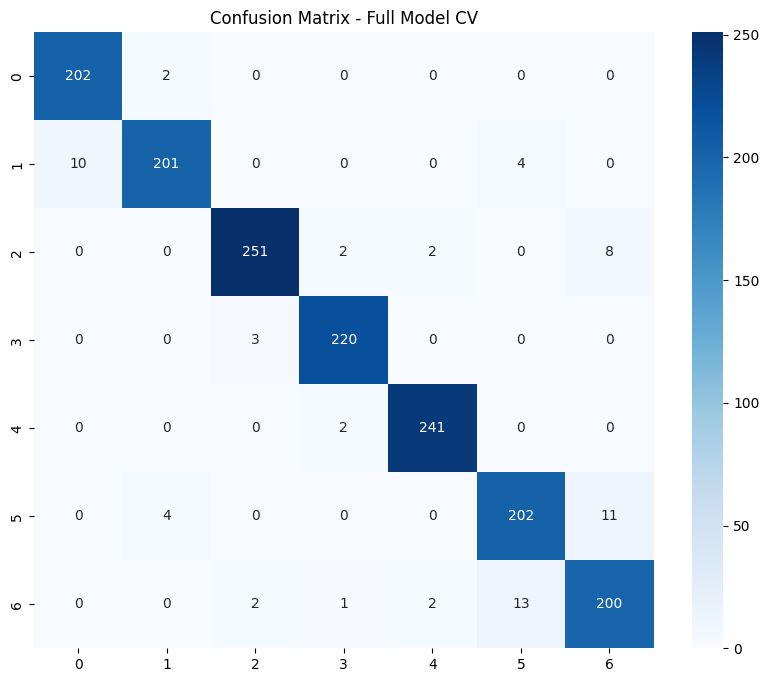

In [15]:
import optuna
from sklearn.model_selection import cross_val_score
#
def objective(trial):
    
    params = {
        'logisticregression__C': trial.suggest_float('C', 0.001, 1000, log=True),
        'logisticregression__penalty': trial.suggest_categorical('penalty', ['l2', 'l1', 'elasticnet']),
        'logisticregression__solver': trial.suggest_categorical('solver', ['lbfgs', 'newton-cg', 'sag', 'saga', 'liblinear']),
        'logisticregression__max_iter': trial.suggest_int('max_iter', 100, 2000),
        'logisticregression__class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'logisticregression__multi_class': trial.suggest_categorical('multi_class', ['ovr', 'multinomial', 'auto'])
    }
    
    if params['logisticregression__penalty'] == 'elasticnet':
        params['logisticregression__l1_ratio'] = trial.suggest_float('l1_ratio', 0, 1)
        params['logisticregression__solver'] = 'saga'
    
    solver = params['logisticregression__solver']
    penalty = params['logisticregression__penalty']
    
    if penalty == 'l1' and solver not in ['liblinear', 'saga']:
        # Пропускаем несовместимые комбинации
        return float('-inf')
    
    if penalty == 'elasticnet' and solver != 'saga':
        return float('-inf')
    
    if solver == 'liblinear' and params['logisticregression__multi_class'] == 'multinomial':
        return float('-inf')
    
    pipeline = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            random_state=42,
            **{k.replace('logisticregression__', ''): v 
               for k, v in params.items() 
               if k.startswith('logisticregression__')}
        )
    )
    
    stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    try:
        scores = cross_val_score(
            pipeline, 
            X_train, 
            y_train, 
            cv=stratified_kfold, 
            scoring='f1_weighted',
            n_jobs=-1
        )
        return scores.mean()
    except Exception as e:
        # Если возникает ошибка (несовместимые параметры), возвращаем плохой результат
        return float('-inf')


#


study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner()
)

study.optimize(objective, n_trials=100, show_progress_bar=True)

print("\nЛучшие параметры:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

best_params = study.best_params.copy()

# Создаем финальный пайплайн с лучшими параметрами
best_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        random_state=42,
        C=best_params['C'],
        penalty=best_params['penalty'],
        solver=best_params['solver'],
        max_iter=best_params['max_iter'],
        class_weight=best_params['class_weight'],
        multi_class=best_params['multi_class'],
        l1_ratio=best_params.get('l1_ratio', None)
    )
)

stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred_cv_full = cross_val_predict(estimator=best_pipeline, 
                                   X=X_train,
                                   y=y_train,
                                   cv=stratified_kfold, 
                                   n_jobs=-1)

print("Classification Report - Full Model CV:")
print(classification_report(y_train, y_pred_cv_full, target_names=y.unique()))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_train, y_pred_cv_full), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Full Model CV')
plt.show()


[I 2025-12-25 22:46:07,309] A new study created in memory with name: polynomial_logistic_regression


Запуск Optuna оптимизации для полиномиальной логистической регрессии...


Best trial: 0. Best value: 0.375672:   1%|          | 1/150 [00:21<53:57, 21.73s/it]

[I 2025-12-25 22:46:29,036] Trial 0 finished with value: 0.3756723794829865 and parameters: {'degree': 2, 'interaction_only': True, 'include_bias': True, 'C': 0.008629132190071854, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 850, 'class_weight': None, 'multi_class': 'auto'}. Best is trial 0 with value: 0.3756723794829865.


Best trial: 1. Best value: 0.816501:   1%|▏         | 2/150 [00:44<55:37, 22.55s/it]

...

[I 2025-12-25 22:54:48,811] Trial 147 finished with value: 0.9526237306480546 and parameters: {'degree': 1, 'interaction_only': False, 'include_bias': True, 'C': 136.0762808312886, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 907, 'class_weight': 'balanced', 'multi_class': 'auto'}. Best is trial 86 with value: 0.9583138168821179.


Best trial: 86. Best value: 0.958314:  99%|█████████▉| 149/150 [08:43<00:00,  1.21it/s]

[I 2025-12-25 22:54:50,634] Trial 148 finished with value: 0.8521833567837456 and parameters: {'degree': 3, 'interaction_only': True, 'include_bias': False, 'C': 429.06721100031984, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 873, 'class_weight': 'balanced', 'multi_class': 'auto'}. Best is trial 86 with value: 0.9583138168821179.


Best trial: 86. Best value: 0.958314: 100%|██████████| 150/150 [08:45<00:00,  3.51s/it]


[I 2025-12-25 22:54:53,144] Trial 149 finished with value: 0.9217274696877185 and parameters: {'degree': 1, 'interaction_only': False, 'include_bias': False, 'C': 954.542450961436, 'penalty': 'l1', 'solver': 'saga', 'max_iter': 708, 'class_weight': None, 'multi_class': 'auto'}. Best is trial 86 with value: 0.9583138168821179.

ЛУЧШИЕ ПАРАМЕТРЫ:
  degree: 1
  interaction_only: False
  include_bias: False
  C: 288.74175242201375
  penalty: l2
  solver: lbfgs
  max_iter: 938
  class_weight: balanced
  multi_class: auto

Лучшая f1-оценка (кросс-валидация): 0.9583

Обучение финальной модели с лучшими параметрами...

РЕЗУЛЬТАТЫ НА ТЕСТОВЫХ ДАННЫХ:
                     precision    recall  f1-score   support

Insufficient_Weight       0.97      1.00      0.99        68
      Normal_Weight       0.96      0.94      0.95        72
     Obesity_Type_I       0.98      0.99      0.98        88
    Obesity_Type_II       0.99      0.97      0.98        74
   Obesity_Type_III       1.00      0.99    

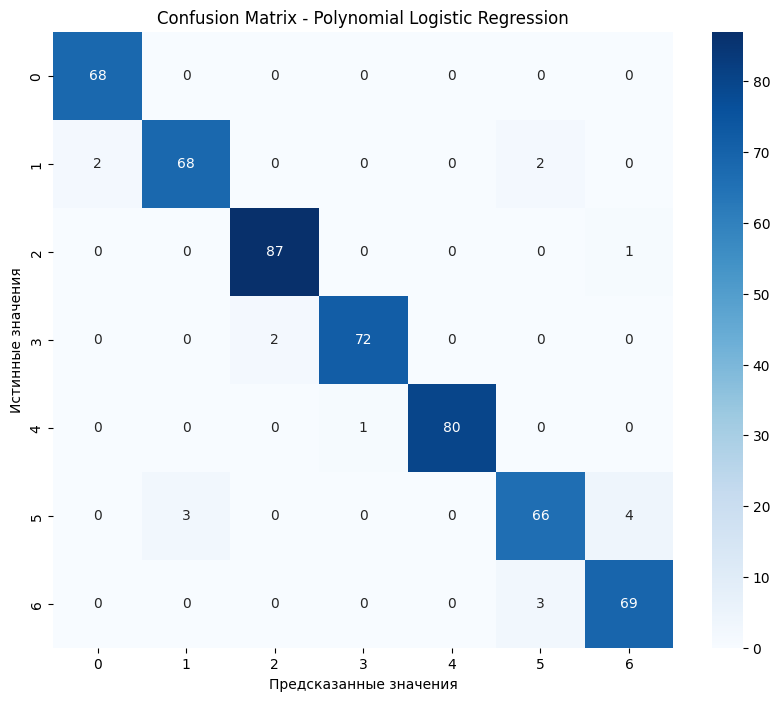


АНАЛИЗ ОПТУНЫ:
Всего испытаний: 150
Успешных испытаний: 139

График истории оптимизации...


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [13]:
import optuna
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Определяем целевую функцию для Optuna
def objective(trial):
    # Определяем пространство поиска гиперпараметров
    params = {
        # Параметры PolynomialFeatures
        'poly__degree': trial.suggest_int('degree', 1, 3, step=1),  # Степень от 1 до 3
        'poly__interaction_only': trial.suggest_categorical('interaction_only', [True, False]),
        'poly__include_bias': trial.suggest_categorical('include_bias', [True, False]),
        
        # Параметры LogisticRegression
        'clf__C': trial.suggest_float('C', 0.001, 1000, log=True),
        'clf__penalty': trial.suggest_categorical('penalty', ['l2', 'l1', 'elasticnet']),
        'clf__solver': trial.suggest_categorical('solver', ['lbfgs', 'saga', 'liblinear']),
        'clf__max_iter': trial.suggest_int('max_iter', 100, 1000),
        'clf__class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'clf__multi_class': trial.suggest_categorical('multi_class', ['ovr', 'multinomial', 'auto'])
    }
    
    # Добавляем l1_ratio если penalty='elasticnet'
    if params['clf__penalty'] == 'elasticnet':
        params['clf__l1_ratio'] = trial.suggest_float('l1_ratio', 0, 1)
        # Для elasticnet нужен только solver='saga'
        params['clf__solver'] = 'saga'
    
    # Получаем значения для проверки совместимости
    solver = params['clf__solver']
    penalty = params['clf__penalty']
    multi_class = params['clf__multi_class']
    
    # Проверка совместимости параметров для избежания ошибок
    # 1. elasticnet требует solver='saga'
    if penalty == 'elasticnet' and solver != 'saga':
        return float('-inf')
    
    # 2. liblinear не поддерживает multinomial
    if solver == 'liblinear' and multi_class == 'multinomial':
        return float('-inf')
    
    # 3. lbfgs/newton-cg/sag не поддерживают l1 penalty
    if penalty == 'l1' and solver not in ['liblinear', 'saga']:
        return float('-inf')
    
    # 4. penalty='none' несовместим с некоторыми solver
    if penalty == 'none' and solver not in ['lbfgs', 'newton-cg', 'sag', 'saga']:
        return float('-inf')
    
    # Создаем пайплайн с текущими параметрами
    pipeline = Pipeline([
        ('poly', PolynomialFeatures(
            degree=params['poly__degree'],
            interaction_only=params['poly__interaction_only'],
            include_bias=params['poly__include_bias']
        )),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            random_state=42,
            C=params['clf__C'],
            penalty=params['clf__penalty'],
            solver=params['clf__solver'],
            max_iter=params['clf__max_iter'],
            class_weight=params['clf__class_weight'],
            multi_class=params['clf__multi_class'],
            l1_ratio=params.get('clf__l1_ratio', None)
        ))
    ])
    
    # Используем кросс-валидацию для оценки
    stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    try:
        scores = cross_val_score(
            pipeline, 
            X_train, 
            y_train, 
            cv=stratified_kfold, 
            scoring='f1_weighted',
            n_jobs=-1
        )
        return scores.mean()
    except Exception as e:
        # Если возникает ошибка, возвращаем плохой результат
        # Можно раскомментировать для отладки:
        # print(f"Ошибка с параметрами {params}: {e}")
        return float('-inf')

# Создаем и запускаем исследование Optuna
study = optuna.create_study(
    direction='maximize',  # Максимизируем f1_score
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(),
    study_name='polynomial_logistic_regression'
)

# Запускаем оптимизацию
print("Запуск Optuna оптимизации для полиномиальной логистической регрессии...")
study.optimize(objective, n_trials=150, show_progress_bar=True)

# Выводим лучшие результаты
print("\n" + "="*60)
print("ЛУЧШИЕ ПАРАМЕТРЫ:")
print("="*60)
for key, value in study.best_params.items():
    print(f"  {key}: {value}")
print(f"\nЛучшая f1-оценка (кросс-валидация): {study.best_value:.4f}")
print("="*60)

# Обучаем финальную модель с лучшими параметрами
best_params = study.best_params.copy()

# Подготавливаем параметры для PolynomialFeatures
poly_params = {
    'degree': best_params.get('degree', 2),
    'interaction_only': best_params.get('interaction_only', False),
    'include_bias': best_params.get('include_bias', False)
}

# Подготавливаем параметры для LogisticRegression
logreg_params = {
    'random_state': 42,
    'C': best_params.get('C'),
    'penalty': best_params.get('penalty'),
    'solver': best_params.get('solver'),
    'max_iter': best_params.get('max_iter', 1000),
    'class_weight': best_params.get('class_weight'),
    'multi_class': best_params.get('multi_class')
}

# Добавляем l1_ratio только если penalty='elasticnet'
if best_params.get('penalty') == 'elasticnet' and 'l1_ratio' in best_params:
    logreg_params['l1_ratio'] = best_params['l1_ratio']

# Удаляем None значения
logreg_params = {k: v for k, v in logreg_params.items() if v is not None}

# Создаем финальный пайплайн
best_pipeline = Pipeline([
    ('poly', PolynomialFeatures(**poly_params)),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(**logreg_params))
])

# Обучаем на всех тренировочных данных
print("\nОбучение финальной модели с лучшими параметрами...")
best_pipeline.fit(X_train, y_train)

# Тестируем модель на тестовых данных
y_pred = best_pipeline.predict(X_test)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ НА ТЕСТОВЫХ ДАННЫХ:")
print("="*60)
print(classification_report(y_test, y_pred))

# Матрица ошибок
print("\n" + "="*60)
print("МАТРИЦА ОШИБОК:")
print("="*60)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Polynomial Logistic Regression')
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()

# Анализ важности параметров
print("\n" + "="*60)
print("АНАЛИЗ ОПТУНЫ:")
print("="*60)
print(f"Всего испытаний: {len(study.trials)}")
print(f"Успешных испытаний: {len([t for t in study.trials if t.value > float('-inf')])}")

# Визуализация результатов Optuna
if optuna.__version__ >= '3.0.0':
    try:
        import plotly
        
        # Оптимизационная история
        print("\nГрафик истории оптимизации...")
        fig1 = optuna.visualization.plot_optimization_history(study)
        fig1.show()
        
        # Важность гиперпараметров
        print("График важности гиперпараметров...")
        fig2 = optuna.visualization.plot_param_importances(study)
        fig2.show()
        
        # Параллельные координаты
        print("График параллельных координат...")
        fig3 = optuna.visualization.plot_parallel_coordinate(study)
        fig3.show()
        
    except ImportError:
        print("\nДля визуализации установите plotly: pip install plotly")
else:
    print("\nДля визуализации обновите optuna до версии 3.0.0: pip install --upgrade optuna")

# Дополнительный анализ: сравнение с обычной логистической регрессией
print("\n" + "="*60)
print("СРАВНЕНИЕ С ОБЫЧНОЙ ЛОГИСТИЧЕСКОЙ РЕГРЕССИЕЙ:")
print("="*60)

# Создаем обычную логистическую регрессию (без полиномов)
simple_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        random_state=42,
        C=best_params.get('C', 1),
        penalty=best_params.get('penalty', 'l2'),
        solver=best_params.get('solver', 'lbfgs'),
        max_iter=best_params.get('max_iter', 1000),
        class_weight=best_params.get('class_weight', None),
        multi_class=best_params.get('multi_class', 'auto')
    )
)

# Обучаем и оцениваем
simple_pipeline.fit(X_train, y_train)
y_pred_simple = simple_pipeline.predict(X_test)

print("\nОбычная логистическая регрессия:")
print(classification_report(y_test, y_pred_simple))

# Сравниваем accuracy
accuracy_poly = accuracy_score(y_test, y_pred)
accuracy_simple = accuracy_score(y_test, y_pred_simple)

print(f"\nТочность полиномиальной регрессии: {accuracy_poly:.4f}")
print(f"Точность обычной регрессии: {accuracy_simple:.4f}")
print(f"Разница: {accuracy_poly - accuracy_simple:.4f}")